# Lab 7 Template

## Preliminary

### Packages to install

- ucimlrepo (for grabbing datasets)
- transformers
- autogen
- jupyter (if you aren't on the latest version, there's a dependency in tqdm that complains)

#### Install with pip

- pip install ucimlrepo transformers autogen jupyter

### From lab 3

- pandas, numpy, matplotlib.pyplot, seaborn, tqdm, torch, sklearn

#### Install everything with pip

- pip install ucimlrepo transformers autogen pandas numpy matplotlib seaborn tqdm torch scikit-learn jupyter

In [ ]:
# If you need to install stuff on colab
!pip install ucimlrepo transformers autogen pandas numpy matplotlib seaborn tqdm torch scikit-learn jupyter

### Intro

The goal of this lab is to give you an idea of how you could use agents to help with physics tasks. It will also introduce you to AutoGen, one of the more popular frameworks at the moment for designing custom agentic workflows. We won't make use of all the tools it provides, just the very basics. Note also that many of the most interesting things one can do with AI-powered agents (see topics like retreival augmented generation (RAG)) require very large models to be performant, and many techniques require continuous/repeated training. This means large resource requirements, so for this lab we will just be using a very small LLM (Llama: TinyLlama-1.1B-Chat-v1.0). The results from this are nowhere near as good as something like chatGPT, but it should give you an idea of how a more advanced model (or models) might be able to do something really helpful/cool. This is an area of current research, so it will be interesting to see what they can do!

Also because of the limited size of the model, the text parsing needs to be very mechanical, and in some places a bit obtuse. The better (and ideally specially trained for an agentic workflow, see RAG) your model is, the more this can be relaxed. If you're interested in working with agents in a more user-friendly way (hiding a lot of the mechanics that are on display here), check out sites like n8n or Google Gemini (be aware that these can require you to provide a lot of permissions). You can also feel free to replace TinyLlama with a call to a larger model using API keys if you have some.

Finally, we would like to emphasize the use of copilot/similar tools for this lab in particular. These are agents too! And they are definitely the most performant agents you have easy access to.


## Lab

- There are two datasets, "mnist" (from Lab 3) and "solar_flare"
- Try to get everything working with mnist, then try adding solar_flare
    - This is one way agents can be helpful, since they can analyze a dataset you've never seen before and take a first crack at it much faster than you can

## Imports

In [ ]:
# Import necessary packages

# Lab 7
# Akhil Samrat
# PHYS 417

%matplotlib inline

from autogen import ConversableAgent, AssistantAgent
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Lab 3 code (run and then minimize this)

- Mostly just lab 3 code packaged into functions

In [ ]:
# Load MNIST Dataset in Numpy
def load_mnist_data():

    BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Lab7_Template/"

    # 1000 training samples where each sample feature is a greyscale image with shape (28, 28)
    # 1000 training targets where each target is an integer indicating the true digit
    mnist_train_features = np.load(BASE_PATH + 'mnist_train_features.npy')
    mnist_train_targets = np.load(BASE_PATH + 'mnist_train_targets.npy')

    # 100 testing samples + targets
    mnist_test_features = np.load(BASE_PATH + 'mnist_test_features.npy')
    mnist_test_targets = np.load(BASE_PATH + 'mnist_test_targets.npy')

    # Print the dimensions of training sample features/targets
    #print(mnist_train_features.shape, mnist_train_targets.shape)
    # Print the dimensions of testing sample features/targets
    #print(mnist_test_features.shape, mnist_test_targets.shape)

    return mnist_train_features, mnist_train_targets, mnist_test_features, mnist_test_targets


def flatten_features(features):
    # Flatten the features from (28, 28) to (784,)
    return features.reshape(features.shape[0], -1)

def scale_features(features):
    scaler = StandardScaler()
    return scaler.fit_transform(features)

# More general function to load datasets, including solar_flare
def load_dataset(dataset_name: str = ""):
    if dataset_name == "mnist":
        train_features, train_targets, test_features, test_targets = load_mnist_data()
        train_features = flatten_features(train_features)
        test_features = flatten_features(test_features)
        train_features = scale_features(train_features)
        test_features = scale_features(test_features)

    elif dataset_name == "solar_flare":
        # Load the solar flare dataset
        solar_flare = fetch_ucirepo(id=89)

        # Simplifying slightly for the sake of this example
        solar_flare.data.targets = solar_flare.data.targets['severe flares']

        # Split the solar flare dataset into train and test sets (90:10 split)
        train_features, test_features, train_targets, test_targets = train_test_split(
            solar_flare.data.features, solar_flare.data.targets, test_size=0.1, random_state=42
        )

        # Onehot encode modified Zurich class, largest spot size, spot distribution
        onehot_columns = ["modified Zurich class", "largest spot size", "spot distribution"]
        for col in onehot_columns:
            onehot = pd.get_dummies(train_features[col], prefix=col)
            train_features = pd.concat([train_features, onehot], axis=1)
            train_features.drop(col, axis=1, inplace=True)

            onehot = pd.get_dummies(test_features[col], prefix=col)
            test_features = pd.concat([test_features, onehot], axis=1)
            test_features.drop(col, axis=1, inplace=True)

        # Scale the features
        train_features = scale_features(train_features)
        test_features = scale_features(test_features)

        # Convert targets to numpy arrays
        train_targets = train_targets.to_numpy()
        test_targets = test_targets.to_numpy()

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    # train-test split
    train_features, val_features, train_targets, val_targets = train_test_split(train_features, train_targets, test_size=0.2)

    return train_features, train_targets, val_features, val_targets, test_features, test_targets


# Train
def train_model(model, train_features, train_targets, validation_features, validation_targets,
                test_features=None, test_targets=None, learning_rate=0.0015, epochs=80, batch_size=64):
    """
    Train a neural network model on the provided data.

    Parameters:
        model: PyTorch model to train
        train_features: Training features as numpy array
        train_targets: Training targets as numpy array
        validation_features: Validation features as numpy array
        validation_targets: Validation targets as numpy array
        test_features: Test features as numpy array (optional)
        test_targets: Test targets as numpy array (optional)
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs
        batch_size: Batch size for training

    Returns:
        tuple: (trained model, training loss list, validation accuracy list)
    """
    # Initialize tracking lists
    train_loss_list = np.zeros(epochs)
    validation_accuracy_list = np.zeros(epochs)

    # Convert numpy arrays to PyTorch tensors
    train_inputs = torch.from_numpy(train_features).float()
    train_targets = torch.from_numpy(train_targets).long()

    validation_inputs = torch.from_numpy(validation_features).float()
    validation_targets = torch.from_numpy(validation_targets).long()

    if test_features is not None and test_targets is not None:
        test_inputs = torch.from_numpy(test_features).float()
        test_targets = torch.from_numpy(test_targets).long()
        test_dataset = TensorDataset(test_inputs, test_targets)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Create dataloaders
    train_dataset = TensorDataset(train_inputs, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_dataset = TensorDataset(validation_inputs, validation_targets)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

    # Setup optimizer and scheduler
    loss_func = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Move model to GPU if available
    if torch.cuda.is_available():
        model = model.cuda()
        train_inputs = train_inputs.cuda()
        validation_inputs = validation_inputs.cuda()
        validation_targets = validation_targets.cuda()

    # Training Loop
    for epoch in tqdm.trange(epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0

        for batch_inputs, batch_targets in train_loader:
            if torch.cuda.is_available():
                batch_inputs, batch_targets = batch_inputs.cuda(), batch_targets.cuda()

            optimizer.zero_grad()  # Reset gradients to zero
            outputs = model(batch_inputs)  # Forward pass with current batch
            loss = loss_func(outputs, batch_targets)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights

            running_loss += loss.item() * batch_inputs.size(0)

        # Store average epoch loss
        train_loss_list[epoch] = running_loss / len(train_dataset)
        scheduler.step()  # Update learning rate with cosine annealing

        # Compute Validation Accuracy
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():
            correct = 0
            total = 0
            for val_inputs, val_targets in validation_loader:
                if torch.cuda.is_available():
                    val_inputs, val_targets = val_inputs.cuda(), val_targets.cuda()
                outputs = model(val_inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += val_targets.size(0)
                correct += (predicted == val_targets).sum().item()

            validation_accuracy_list[epoch] = correct / total

    # Compute test accuracy if test data is provided
    test_accuracy = None
    if test_features is not None and test_targets is not None:
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for test_inputs, test_targets in test_loader:
                if torch.cuda.is_available():
                    test_inputs, test_targets = test_inputs.cuda(), test_targets.cuda()
                outputs = model(test_inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += test_targets.size(0)
                correct += (predicted == test_targets).sum().item()

            test_accuracy = correct / total

    return model, train_loss_list, validation_accuracy_list, test_accuracy


# Visualize and evaluate
def visualize_training(train_loss_list, validation_accuracy_list):
    """
    Visualize training loss and validation accuracy.

    Parameters:
        train_loss_list: List of training losses
        validation_accuracy_list: List of validation accuracies
    """
    plt.figure(figsize = (12, 6))

    # Visualize training loss with respect to iterations (1 iteration -> single batch)
    plt.subplot(2, 1, 1)
    plt.plot(train_loss_list, linewidth = 3)
    plt.ylabel("training loss")
    plt.xlabel("epochs")
    sns.despine()

    # Visualize validation accuracy with respect to epochs
    plt.subplot(2, 1, 2)
    plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
    plt.ylabel("validation accuracy")
    sns.despine()

    plt.show()



## Define Model(s)

- Here you should make two models, one linear and one convolutional. The agents will use these later.
- Copilot/similar tools are encouraged for this; remember that they are agents too!
- Also you can add more if you want
- Also make sure to reshape the input data to the correct shape. Each model might be given mnist data or later solar_flare data. But these have different shapes! Mnist is AxBx1, but solar_flare is just Ax1
    - You don't need to perfect this on your first pass through, just make sure both with mnist and you can revisit later

In [ ]:
# Fully connected neural network classification model
class fcnClassification(torch.nn.Module):

    def __init__(self, input_size, num_classes=10):

        # Initialize parent PyTorch module
        super(fcnClassification, self).__init__()

        # Model description used by the agents
        self.description = "A fully connected lienar classification model for flattened input data"

        # Flatten image/tabular input into 1D vector
        self.flatten = torch.nn.Flatten()

        # Fully connected hidden layer
        self.linear1 = torch.nn.Linear(input_size, 128)

        # Activation function
        self.relu = torch.nn.ReLU()

        # Output classification layer
        self.linear2 = torch.nn.Linear(128, num_classes)

    def forward(self, x):

        # Flatten input before feeding into linear layers
        x = self.flatten(x)

        # Hidden layer + activation
        x = self.linear1(x)
        x = self.relu(x)

        # Final predictions
        x = self.linear2(x)

        return x


# Uses convolutional layers
class ConvClassification(torch.nn.Module):

    def __init__(self, num_classes=10):

        # Initialize parent pytorch module
        super(ConvClassification, self).__init__()

        # Model description used by the agents
        self.description = "a convolutional neural network classification model for imagelike input data" # YOUR CODE HERE (short str description of the model)

        # First convolutional block
        self.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu = torch.nn.ReLU()
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional layer
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # Flatten cnn feature maps into vector
        self.flatten = torch.nn.Flatten()

        # Fully connected classifier layers
        self.linear1 = torch.nn.Linear(32 * 7 * 7, 128)
        self.linear2 = torch.nn.Linear(128, num_classes)

    def forward(self, x):

        # Reshape flattened mnist vectors into image format
        if x.dim() == 2:
            x = x.view(x.shape[0], 1, 28, 28)

        # Add missing channel dimension if needed
        elif x.dim() == 3:
            x = x.unsqueeze(1)

        # Convolution -> activation -> pooling
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Second convolution block
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # flatten and classify
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)

        return x

# Agents

### DatasetLoader

Here is the definition of the agent that handles dataset loading. The logic is pretty simple, so nothing for you to code here

In [ ]:
class DatasetLoaderAgent(AssistantAgent):
    """
    An agent that specializes in loading and preprocessing datasets.
    """
    def __init__(self, name="DatasetLoader", **kwargs):
        self.available_datasets = ["mnist", "solar_flare"]
        system_message = (
            "I am a dataset loading assistant. I can load and preprocess various datasets for machine learning tasks. "
            f"Currently I support: {', '.join(self.available_datasets)}. "
        )
        super().__init__(name=name, system_message=system_message, **kwargs)

        # Store loaded datasets
        self._loaded_datasets = {}

    def get_available_datasets(self):
        """Return a list of available datasets."""
        return self.available_datasets

    def load_dataset(self, dataset_name):
        """
        Load and preprocess a dataset.

        Args:
            dataset_name (str): Name of the dataset to load

        Returns:
            dict: Information about the loaded dataset and the data itself
        """
        try:
            # Load the dataset using the existing function
            train_features, train_targets, val_features, val_targets, test_features, test_targets = load_dataset(dataset_name)

            # Store the dataset
            self._loaded_datasets[dataset_name] = {
                "train_features": train_features,
                "train_targets": train_targets,
                "validation_features": val_features,
                "validation_targets": val_targets,
                "test_features": test_features,
                "test_targets": test_targets,
            }

            # Return information about the loaded dataset
            return {
                "status": "success",
                "dataset_name": dataset_name,
                "train_samples": train_features.shape[0],
                "validation_samples": val_features.shape[0],
                "test_samples": test_features.shape[0],
                "feature_dim": train_features.shape[1]
            }
        except Exception as e:
            return {
                "status": "error",
                "message": f"Failed to load dataset '{dataset_name}': {str(e)}"
            }

    def get_dataset(self, dataset_name):
        """
        Retrieve a previously loaded dataset.

        Args:
            dataset_name (str): Name of the dataset to retrieve

        Returns:
            dict: The dataset components or None if not found
        """
        return self._loaded_datasets.get(dataset_name)


    # Generate a text description of a loaded dataset
    # so the agent can decide which model to use
    def query_dataset(self, dataset_name):

        # Retrieve dataset from stored loaded datasets
        dataset = self.get_dataset(dataset_name)

        # Return error if dataset hasnt been loaded yet
        if dataset is None:
            return {
                "status": "error",
                "message": f"Dataset '{dataset_name}' has not been loaded yet."
            }

        # Extract dataset components
        train_features = dataset["train_features"]
        train_targets = dataset["train_targets"]
        test_features = dataset["test_features"]
        test_targets = dataset["test_targets"]

        # Build a text description containing dataset shapes
        description = (
            f"The dataset '{dataset_name}' has training features with shape {train_features.shape}, "
            f"training targets with shape {train_targets.shape}, "
            f"test features with shape {test_features.shape}, "
            f"and test targets with shape {test_targets.shape}. "
        )

        # Add dataset specific model recommendations
        if dataset_name == "mnist":
            description += "This is handwritten digit image data, so a convolutional model is appropriate."
        elif dataset_name == "solar_flare":
            description += "This is tabular data, so a linear or fully connected model is appropriate."

        # Return successful query result
        return {
            "status": "success",
            "description": description
        }

### InterfaceAgent

- Setting up the LLM

In [ ]:
# Load the model
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Create a simple text-generation pipeline
llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=200,
    do_sample=True,
    temperature=0.4,
)

# Wrapper function for the local model pipeline
def local_model_generate(prompt):
    output = llm_pipeline(prompt)[0]["generated_text"]
    return output

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


#### Agent definition

- This is the definition of the actual agent you will converse with
- Implement the query and get dataset commands
- You can come back to the train command after you get to the model trainer agent


In [ ]:
# Agent definition
class InterfaceAgent(ConversableAgent):
    def __init__(self, name, **kwargs):
        super().__init__(name, **kwargs)

        self.dataset_loader_agent = None
        self.model_trainer_agent = None

    def set_dataset_loader_agent(self, agent):
        self.dataset_loader_agent = agent

    def set_model_trainer_agent(self, agent):
        self.model_trainer_agent = agent

    def generate_reply(self, messages):
        """
        There is a lot of obtuse text parsing and such here. I would describe the code as "technically functional".
        This is becasue the LLM is so limited. With a better LLM, and/or ideally one trained explicitly for
        agentic implementation, this would be much cleaner and more flexible.
        C.f. retrieval augmented generation, etc.
        """
        # Extract the latest user message
        user_message = messages[-1]["content"]

        # Check if the message is a "get dataset" command
        if "get dataset" in user_message:

            # Parse user input to extract dataset name
            parts = user_message.split()
            dataset_name = parts[-1]

            # Use DatasetLoaderAgent to load dataset
            if self.dataset_loader_agent is not None:
                result = self.dataset_loader_agent.load_dataset(dataset_name)
            else:
                result = {
                    "status": "failure",
                    "message": "Dataset loader agent is not set."
                }

            # Check if the dataset was successfully loaded
            if result["status"] == "success":
                response_text = (
                    f"Successfully loaded dataset '{result['dataset_name']}'.\n"
                    f"Training samples: {result['train_samples']}, "
                    f"Validation samples: {result['validation_samples']}, "
                    f"Test samples: {result['test_samples']}, "
                    f"Feature dimension: {result['feature_dim']}."
                )
            else:
                response_text = f"Failed to load dataset '{dataset_name}': {result['message']}"

        elif "query" in user_message:

            # Parse user input to extract dataset name
            parts = user_message.split()
            dataset_name = parts[-1]

            # Use DatasetLoaderAgent to retrieve dataset information
            if self.dataset_loader_agent is not None:
                result = self.dataset_loader_agent.query_dataset(dataset_name)

                # Generate dataset description using the LLM
                if result["status"] == "success":
                    prompt = (
                        f"Describe the dataset '{dataset_name}' for choosing a machine learning model. "
                        f"Use this information: {result['description']}"
                    )

                    response_text = local_model_generate(prompt)
                else:
                    response_text = f"Failed to query dataset '{dataset_name}': {result['message']}"
            else:
                response_text = "Dataset loader agent is not set."

        elif "train" in user_message:
            # Of the form "train <dataset_name> <model_type>"
            # Again, this is where a specialized LLM would be really useful to avoid this parsing
            # Model type
            parts = user_message.split()
            dataset_name, modeltype = parts[1], parts[2]

            # Use the ModelTrainerAgent to train the model
            if self.model_trainer_agent is not None:

                # If the user specified an available model type, use that directly
                if modeltype in self.model_trainer_agent.available_models:
                    result = self.model_trainer_agent.train_model_on_query(
                        dataset_name,
                        "placeholder",
                        override=modeltype
                    )

                # Otherwise, use the dataset description to decide on the model type
                else:

                    # Query dataset information from DatasetLoaderAgent
                    query_result = self.dataset_loader_agent.query_dataset(dataset_name)

                    # Generate an LLM dataset description to help choose between a linear or convolutional model
                    if query_result["status"] == "success":
                        prompt = (
                            f"Describe the dataset '{dataset_name}' for choosing between a linear model "
                            f"and a convolutional model. Use this information: {query_result['description']}"
                        )

                        dataset_description = local_model_generate(prompt)
                    else:
                        dataset_description = ""

                    # Use generated dataset description to train the model
                    result = self.model_trainer_agent.train_model_on_query(
                        dataset_name,
                        dataset_description
                    )

                if result["status"] == "success":
                    response_text = f"Successfully trained the model '{modeltype}'."
                else:
                    response_text = f"Failed to train the model '{modeltype}': {result['response']}"
            else:
                response_text = "Model trainer agent is not set."

        # No special command, just a normal message. Can just use the model as a chatbot
        else:
            response_text = local_model_generate(user_message)

        # Return the response in the Autogen format
        return {"role": "assistant", "content": response_text}

## Talk to the datasetloader

In [ ]:
# Create instances of the agents
dataset_loader_agent = DatasetLoaderAgent(name="DatasetLoader")
local_agent = InterfaceAgent(name="LocalAgent")
local_agent.set_dataset_loader_agent(dataset_loader_agent)

# Simulate a conversation
messages = [{"role": "user", "content": "get dataset mnist"}]

# InterfaceAgent processes the first message
response = local_agent.generate_reply(messages)
print(response["content"])
print()

# Add a second message to the conversation, querying mnist


messages.append({"role": "user", "content": "query mnist"})

response = local_agent.generate_reply(messages)
print(response["content"])


# You can also use the model as a chatbot
messages.append({"role": "user", "content": "Why don't whales have feet?"})
response = local_agent.generate_reply(messages)
print(response["content"])
print()

# Note that the output is not reliable at all since the model is tiny. Sometimes it's surprisingly good though

Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Successfully loaded dataset 'mnist'.
Training samples: 800, Validation samples: 200, Test samples: 100, Feature dimension: 784.



Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Describe the dataset 'mnist' for choosing a machine learning model. Use this information: The dataset 'mnist' has training features with shape (800, 784), training targets with shape (800,), test features with shape (100, 784), and test targets with shape (100,). This is handwritten digit image data, so a convolutional model is appropriate. The dataset was split into training and testing sets with a 80%/20% split. The training data is used to train the model and the testing data is used to evaluate the model's performance. The dataset is used for training a convolutional neural network (CNN) model. The model is trained using the `fit_generator` function with batch size 32, learning rate 0.001, and epochs 5. The model is then evaluated using the test data. The model's accuracy is reported on the test data.
Why don't whales have feet?

Scientist 1: That's a fascinating question, and one that has been debated for centuries. Some scientists believe that whales evolved without feet, while o

## Model Trainer

This is the agent that actually trains a model for analyzing the dataset. In InterfaceAgent, the train command should generate a description of the dataset and feed it to the train_model_on_query method below (if the user didn't explicitly specify a model type). So use the LLM to generate a recommended model type from the description ("query").

If you want, you could implement some more complex logic here, getting the LLM to recommend hyperparameters and things like that. There is also some amount of talking back and forth with itself here, in a chain-of-reasoning style. With a much bigger model, you could start to see some really interesting behavior here. This is what gives DeepSeek its power!

#### Note

Be careful with how you handle the input dimensions for your models. Convolutional networks want different dimensions than an fully linear network. I recommend making it so that you can feed them the data, and the model itself handles any reshaping needs.

In [ ]:
class ModelTrainerAgent(ConversableAgent):
    """
    An agent that selects, creates, and trains a classification model based on the user's query.
    """
    def __init__(self, name="ModelTrainer", dataset_loader_agent=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.dataset_loader_agent = dataset_loader_agent

        self.model = None
        self.train_loss_list = None
        self.val_accuracy_list = None
        self.test_accuracy = None

        self.available_models = ["linear", "conv"]


    def train_model_on_query(self, dataset_name, query, override=None):
        """
        Parse the query, select the model, and train it on the dataset.
        """
        try:

            # Retrieve the dataset from the DatasetLoaderAgent
            dataset = self.dataset_loader_agent.get_dataset(dataset_name)
            if not dataset:
                return {"status": "error", "response": f"Dataset '{dataset_name}' is not loaded or does not exist."}

            # Extract dataset components
            train_features = dataset["train_features"]
            train_targets = dataset["train_targets"]
            val_features = dataset["validation_features"]
            val_targets = dataset["validation_targets"]
            test_features = dataset["test_features"]
            test_targets = dataset["test_targets"]

            # Get a response from the LLM recommending a model based on query

            # If the user explicitly specifies a model type, use that model directly
            if override is not None:
                model_type = override

            # Otherwise, let the agent decide which model to use
            else:

                # Force solar_flare to use a linear model since it is tabular rather than image data
                if dataset_name == "solar_flare":
                    model_type = "linear"

                # Use the LLM to recommend a model type
                else:
                    llm_response = local_model_generate(query)
                    llm_response_lower = llm_response.lower()

                    # Select convolutional model if LLM mentions
                    # conv/convolutional/image-like features
                    if "conv" in llm_response_lower or "convolutional" in llm_response_lower or "2d" in llm_response_lower:
                        model_type = "conv"

                    # Select fully connected model if LLM mentions
                    # linear/fcn/fully connected networks
                    elif "linear" in llm_response_lower or "fcn" in llm_response_lower or "fully connected" in llm_response_lower:
                        model_type = "linear"

                    # Default fallback model
                    else:
                        model_type = "conv"

            # Determine input dimension based on dataset shape
            # MNIST images have shape (batch, 28, 28)
            # Tabular datasets like solar_flare have shape (batch, features)
            if len(train_features.shape) == 3:
                indim = train_features.shape[1] * train_features.shape[2]
            else:
                indim = train_features.shape[1]



            # Print training/debugging information

            print(f"Training model of type '{model_type}' on dataset '{dataset_name}' with input dimension {indim}.")
            print(f"Training features shape: {train_features.shape}")
            print(f"Training targets shape: {train_targets.shape}")

            # Select the model based on the model_type
            if model_type == "linear":
                model = fcnClassification(input_size=indim)
            elif model_type == "conv":
                model = ConvClassification()
            else:
                model = ConvClassification()

            # Train the model
            self.model, self.train_loss_list, self.val_accuracy_list, self.test_accuracy = train_model(
                model,
                train_features,
                train_targets,
                val_features,
                val_targets,
                test_features=test_features,
                test_targets=test_targets
            )

            response = (
                f"Model '{model_type}' trained successfully on dataset '{dataset_name}'.\n"
                f"Final validation accuracy: {self.val_accuracy_list[-1]:.4f}\n"
                f"Test accuracy: {self.test_accuracy:.4f}"
            )
            print("Training response:", response)

            result = {
                "role": "assistant",
                "status": "success",
                "model": self.model,
                "train_loss_list": self.train_loss_list,
                "val_accuracy_list": self.val_accuracy_list,
                "test_accuracy": self.test_accuracy,
                "response": response
            }

            return result

        except Exception as e:
            return {"status": "error", "response": f"An error occurred during training: {str(e)}"}

## Train a model on mnist

- Get the dataset and train a model on it
- You can try specifying, but make sure the LLM can recommend a model type itself
- The mnist dataset is very well known, so it should decide on the convolutional model itself (up to the output being bad becasue of the small model)

In [ ]:
# Create instances of the agents
dataset_loader_agent = DatasetLoaderAgent(name="DatasetLoader")
model_trainer_agent = ModelTrainerAgent(name="ModelTrainer", dataset_loader_agent=dataset_loader_agent)
local_agent = InterfaceAgent(name="LocalAgent")

local_agent.set_dataset_loader_agent(dataset_loader_agent)
local_agent.set_model_trainer_agent(model_trainer_agent)

# Send a request to the agent to load the mnist dataset
messages = [{"role": "user", "content": "get dataset mnist"}]
response = local_agent.generate_reply(messages)
print(response["content"])
print()

# Send a request to the agent to train a model on the mmist dataset
messages.append({"role": "user", "content": "train mnist random"})
response = local_agent.generate_reply(messages)
print(response["content"])
print()

# And you now have a trained model!
print(model_trainer_agent.model)

Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Successfully loaded dataset 'mnist'.
Training samples: 800, Validation samples: 200, Test samples: 100, Feature dimension: 784.



Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Training model of type 'conv' on dataset 'mnist' with input dimension 784.
Training features shape: (800, 784)
Training targets shape: (800,)


100%|██████████| 80/80 [00:08<00:00,  8.97it/s]

Training response: Model 'conv' trained successfully on dataset 'mnist'.
Final validation accuracy: 0.8800
Test accuracy: 0.9100
Successfully trained the model 'random'.

ConvClassification(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=1568, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=10, bias=True)
)


## Repeat with solar_flare

Now that everything's working, try adding the solar_flare dataset in.

- Add solar_flare to the list of available datasets in the datasetloader
    - The backend stuff for this is already in the lab 3 code
        - This would not be too bad to fit into the agents in principle
- The other agents shouldn't need any additional modification, unless you wrote mnist-specific code
    - Ignore that the models have mnist in the name, they aren't necessarily mnist specific
    - This is easy to do without intending to. The more generalized your code, the better
    - Try throwing any errors you get to copilot as a first pass. It's good at generalizing code

- In the end, you should be able to tell the agent "train 'dataset' 'random'", and it should be able to select and train a linear model if dataset=solar_flare or a convolutional model if dataset=mnist
    - Of course, up to LLM inconsistency
    - With a good model/more complex logic, it should be able to do this for many different models and any random dataset you throw at it
        - Very useful for taking a first crack at a dataset and getting a starting point
        - This entire step could also be implemented as a "copilot, figure out how to add 'dataset'" command with a model as good as copilot hooked into this

Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Successfully loaded dataset 'solar_flare'.
Training samples: 1000, Validation samples: 250, Test samples: 139, Feature dimension: 23.

Training model of type 'linear' on dataset 'solar_flare' with input dimension 23.
Training features shape: (1000, 23)
Training targets shape: (1000,)


100%|██████████| 80/80 [00:04<00:00, 17.41it/s]


Training response: Model 'linear' trained successfully on dataset 'solar_flare'.
Final validation accuracy: 0.9920
Test accuracy: 0.9928
Successfully trained the model 'random'.

fcnClassification(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=23, out_features=128, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=128, out_features=10, bias=True)
)


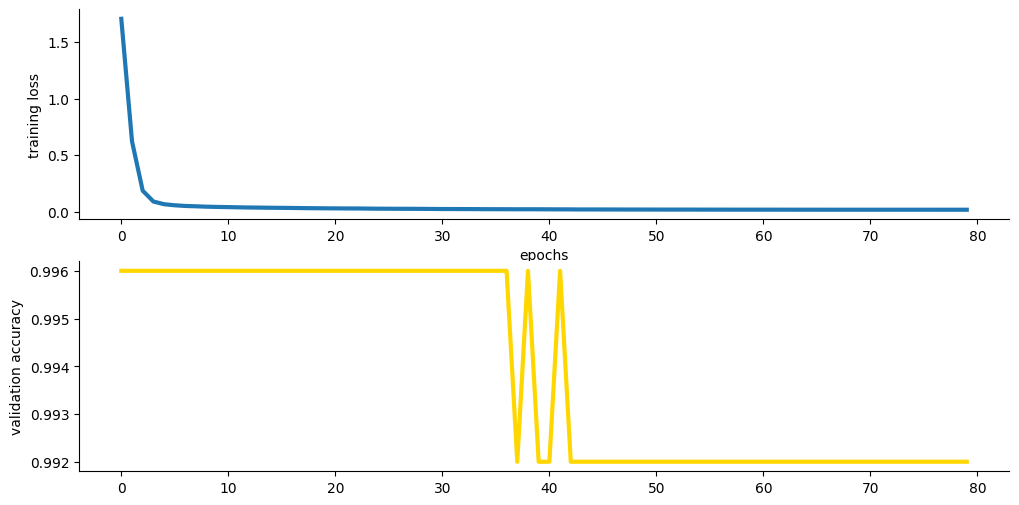

In [ ]:


# Start a new conversation asking the agent to load the solar_flare dataset
messages = [{"role": "user", "content": "get dataset solar_flare"}]

# Generate and print dataset loading response
response = local_agent.generate_reply(messages)
print(response["content"])
print()

# Ask the agent to automatically choose and train a model
# on the solar_flare dataset
messages.append({"role": "user", "content": "train solar_flare random"})

# Generate and print training response
response = local_agent.generate_reply(messages)
print(response["content"])
print()

# Print the final trained model architecture
print(model_trainer_agent.model)

# Plot training loss and validation accuracy curves
visualize_training(
    model_trainer_agent.train_loss_list,
    model_trainer_agent.val_accuracy_list
)